In [ ]:
import numpy as np
print(np.__version__)


1.26.4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install "numpy<2"
!pip install flaml[hf]
!pip install flaml[notebook]
!pip install optuna
!pip install evaluate
!pip install flaml[catboost]

!pip install "datasets<=2.14.5"
!pip install dask



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 119.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-h

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 23.8 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ffc9e41087521e8dd5c08689236987205ebd4b09db38941f351331702e5b7426
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=ed24db31fd5972ac0ccc99e73ee9d87a4c0c29f00bb80635054966e0965059ff
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built rouge_score seqeval
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Success

0.13.0


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from flaml import AutoML
import imblearn
import dask.dataframe as dd
from dask import delayed, compute
#from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif , mutual_info_classif
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, roc_auc_score, matthews_corrcoef, confusion_matrix , accuracy_score
#from imblearn.metrics import geometric_mean_score
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, classification_report
#import matplotlib.pyplot as plt
#from  lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import ipaddress
from collections import Counter
from sklearn.linear_model import LogisticRegression

#from xgboost import XGBClassifier
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import f1_score
from joblib import parallel_backend
import os
import shap
from sklearn.metrics import matthews_corrcoef
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, matthews_corrcoef
#import torch
import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.features import FeatureImportances
from sklearn.ensemble import RandomForestClassifier
#import optuna
import numpy as np
from imblearn.under_sampling import RandomUnderSampler#import neptune
from matplotlib_venn import venn2
from sklearn.inspection import permutation_importance
from matplotlib_venn import venn3
from sklearn.metrics import recall_score
# Check if GPU is available


In [ ]:
file_path_train = "/content/drive/My Drive/Colab Notebooks/kdd/KDDTrain+.txt"
file_path_test = "/content/drive/My Drive/Colab Notebooks/kdd/KDDTest+.txt"

data = pd.read_csv(file_path_train)
train_df = data.copy()


datatest = pd.read_csv(file_path_test)

test_df = datatest.copy()
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','attack','level'])

train_df.columns = columns
test_df.columns = columns


attack_mapping = {
    # DoS
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',
    'apache2': 'DoS',
    'udpstorm': 'DoS',
    'processtable': 'DoS',
    'mailbomb': 'DoS',

    # Probe
    'satan': 'Probe',
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',

    # R2L
    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',
    'snmpgetattack': 'R2L',
    'snmpguess': 'R2L',
    'httptunnel': 'R2L',
    'sendmail': 'R2L',
    'named': 'R2L',
    'xlock': 'R2L',
    'xsnoop': 'R2L',
    'worm': 'R2L',

    # U2R
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R',

    # Normal
    'normal': 'Normal'
}


train_df['attack_category'] = train_df['attack'].map(attack_mapping)
test_df['attack_category'] = test_df['attack'].map(attack_mapping)

full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)



# =========================================================================
# CRITICAL COMPONENT: BEHAVIORAL DEDUPLICATION & LEAKAGE FIX
# =========================================================================
print(f"Shape before behavioral deduplication: {full_df.shape}")
full_df = full_df.drop_duplicates()
print(f"Shape after behavioral deduplication: {full_df.shape}")
# ========================================================================

#train_work = train_df.copy()

#train_split, val_split = train_test_split( train_work, test_size=0.15, random_state=42, stratify=train_work['attack_category'] )

X_global = full_df.drop(columns=['attack_category','level','attack'])
y_global = full_df['attack_category']

X_train_global, X_temp, y_train_global, y_temp = train_test_split(
    X_global,
    y_global,
    test_size=0.30,           # 30% goes to temp
    random_state=42,
    stratify=y_global
)

X_val_global, X_test_global, y_val_global, y_test_global = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,           # half of temp → 15% of total
    random_state=42,
    stratify=y_temp
)

train_df = X_train_global.copy()
train_df['attack_category'] = y_train_global.values

val_df = X_val_global.copy()
val_df['attack_category'] = y_val_global.values

test_df = X_test_global.copy()
test_df['attack_category'] = y_test_global.values


print(train_df['attack_category'].value_counts())
print(val_df['attack_category'].value_counts())
print(test_df['attack_category'].value_counts())


Shape before behavioral deduplication: (148515, 44)
Shape after behavioral deduplication: (147905, 44)
attack_category
Normal    53876
DoS       37089
Probe      9768
R2L        2717
U2R          83
Name: count, dtype: int64
attack_category
Normal    11545
DoS        7947
Probe      2093
R2L         583
U2R          18
Name: count, dtype: int64
attack_category
Normal    11545
DoS        7948
Probe      2093
R2L         582
U2R          18
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

def fit_ohe(df, categorical_cols):
    # Setting handle_unknown='ignore' perfectly covers any rare flags found only in test data!
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    ohe.fit(df[categorical_cols])
    return ohe

def transform_ohe(df, categorical_cols, ohe):
    # 1. Generate the correct feature names
    ohe_cols = ohe.get_feature_names_out(categorical_cols)

    # 2. Transform to numpy array
    ohe_vals = ohe.transform(df[categorical_cols])

    # FIX: Explicitly preserve the original split index to prevent NaN alignment bugs
    ohe_df = pd.DataFrame(ohe_vals, columns=ohe_cols, index=df.index)

    # 3. Drop legacy features and concatenate the clean one-hot frame
    df = df.drop(columns=categorical_cols)
    df = pd.concat([df, ohe_df], axis=1)

    return df

# --- Execution ---
categorical_cols = ['protocol_type', 'service', 'flag']

# 1. Fit ONLY on train to avoid data leakage (Reviewer #1 requirement)
ohe = fit_ohe(train_df, categorical_cols)

# 2. Transform all splits using the identical structural mapping
train_df = transform_ohe(train_df, categorical_cols, ohe)
val_df   = transform_ohe(val_df, categorical_cols, ohe)
test_df  = transform_ohe(test_df, categorical_cols, ohe)

print("One-hot encoding successfully completed with matched structural indices!")
print(f"Train Shape: {train_df.shape} | Val Shape: {val_df.shape} | Test Shape: {test_df.shape}")

One-hot encoding successfully completed with matched structural indices!
Train Shape: (103533, 122) | Val Shape: (22186, 122) | Test Shape: (22186, 122)


In [ ]:
print(train_df['attack_category'].value_counts())
print(test_df['attack_category'].value_counts())
print(val_df['attack_category'].value_counts())



attack_category
Normal    53876
DoS       37089
Probe      9768
R2L        2717
U2R          83
Name: count, dtype: int64
attack_category
Normal    11545
DoS        7948
Probe      2093
R2L         582
U2R          18
Name: count, dtype: int64
attack_category
Normal    11545
DoS        7947
Probe      2093
R2L         583
U2R          18
Name: count, dtype: int64


In [ ]:
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_category
114435,1328,udp,other,SF,146,105,0,0,0,0,...,2,0.01,0.84,1.00,0.00,0.00,0.0,0.00,0.0,Normal
130240,0,tcp,http,SF,273,361,0,0,0,0,...,255,1.00,0.00,0.00,0.01,0.00,0.0,0.00,0.0,Normal
14410,0,tcp,http,SF,323,4822,0,0,0,0,...,51,1.00,0.00,0.02,0.00,0.00,0.0,0.00,0.0,Normal
145984,0,tcp,other,REJ,0,0,0,0,0,0,...,1,0.00,0.91,0.00,0.00,0.16,0.0,0.84,1.0,Probe
118174,0,tcp,nnsp,S0,0,0,0,0,0,0,...,13,0.05,0.06,0.00,0.00,1.00,1.0,0.00,0.0,DoS


In [ ]:
len(val_df.columns)

122

In [ ]:
from math import pi
file_path = "/content/drive/My Drive/Colab Notebooks/kdd/"
files = os.listdir(file_path)



def get_best_features(file_path, num_features,importance_name):
    """
    Returns the top 'num_features' based on ANOVA F-score for a given label.

    Parameters:
    - label: The attack type label.
    - file_path: Path to the feature importance files.
    - num_features: Number of top features to select (default is 22).

    Returns:
    - List of selected features.
    """
    # Load feature importance file
    importance = pd.read_csv(file_path)

    # Sort by ANOVA F-score in descending order
    importance = importance.sort_values(by=importance_name, ascending=False)
    # Select top features
    selected_features = importance.head(num_features)['Feature'].tolist()
    return selected_features

files = os.listdir(file_path)
print("Files in directory:", files)


ANOVA_features = get_best_features( file_path+f"inbalance_anova_kdd.csv",30,"ANOVA F-score")
PI_features = get_best_features( file_path+f"inbalance_PI_kdd.csv",30,"Permutation Importance")
MI_features = get_best_features( file_path+f"inbalance_MI_kdd.csv",30,"Mutual Information")
SHAP_features = get_best_features( file_path+f"inbalance_SHAP_kdd.csv",30,"SHAP Importance")










print(len(ANOVA_features))
print(len(MI_features))
print(SHAP_features)


Files in directory: ['Major Rev 2', 'KDDTrain+.txt', 'KDDTest+.txt', 'ctgan_augmented_train_data_500u2r_1000r2l.csv', 'tva_augmented_train_data_500u2r_1000r2l.csv', 'TVASynthetizer kdd .ipynb', 'copu_augmented_train_data_500u2r_1000r2l.csv', 'CopulaGAN kdd .ipynb', 'Copu kdd Multiclass 2017 faml.ipynb', 'ctgan_augmented_train_data_2500u2r_2500r2l.csv', 'ctgan_augmented_train_data_1000u2r_2500r2l.csv', 'ctgan_augmented_train_data_2500u2r_1000r2l.csv', 'ctgan_augmented_train_data_2000u2r.csv', 'ctgan_augmented_train_data_3000u2r.csv', 'ctgan_augmented_train_data_1000u2r.csv', 'CTGAN kdd .ipynb', 'Z_train_contrastive_only.npy', 'Z_val_contrastive_only.npy', 'Z_test_contrastive_only.npy', 'y_train_enc.npy', 'y_val_enc.npy', 'y_test_enc.npy', 'contrastive_view_train.csv', 'contrastive_view_val.csv', 'contrastive_view_test.csv', 'kdd_u2r_features.csv', 'kdd_r2l_features.csv', 'KDD_Diffusion_Contrastive_augmentation.ipynb', 'ddpm kdd .ipynb', 'ddpm_augmented_train_data_500u2r_1000r2l.csv', 'd

In [ ]:
X_train = train_df.drop(columns=['attack_category'])
y_train = train_df['attack_category']

datasets = {}

#datasets["imbalanced"] = (X_train, y_train)  # No resampling

datasets = {
    "imbalanced": (X_train, y_train),  # No resampling
   # "balanced_1_to_1": {},
    "balanced_1_to_10": {},
    "balanced_1_to_20": {},
    "balanced_max_30k": {}
}

# 1. Separate malicious and benign samples from the original training set
malicious_mask = y_train != "Normal"
X_malicious_orig = X_train[malicious_mask]
y_malicious_orig = y_train[malicious_mask]

X_benign_orig = X_train[~malicious_mask]
# y_benign_orig = y_train[~malicious_mask] # We know these are 'BENIGN'

# 2. Calculate the total number of malicious samples
n_malicious_total = len(y_malicious_orig)
print(f"Total number of malicious samples in original training set: {n_malicious_total}")

n_benign_available = len(X_benign_orig)

if n_malicious_total == 0:
    print("Warning: No malicious samples found in the training set. Cannot create this balanced dataset.")
elif n_benign_available == 0:
    print("Warning: No benign samples found in the training set. Cannot create this balanced dataset.")
else:
    if n_malicious_total > n_benign_available:
        print(f"Warning: Not enough benign samples ({n_benign_available}) available to match total malicious count ({n_malicious_total}).")
        print(f"Using all {n_benign_available} available benign samples.")
        n_benign_to_sample = n_benign_available
    else:
        n_benign_to_sample = n_malicious_total
        print(f"Sampling {n_benign_to_sample} benign samples to match total malicious count.")

    # 4. Randomly sample the required number of benign samples
    X_benign_sampled = X_benign_orig.sample(n=n_benign_to_sample, random_state=42)
    # Create corresponding benign labels
    y_benign_sampled = pd.Series(["Normal"] * n_benign_to_sample, index=X_benign_sampled.index)

    # 5. Combine the sampled benign samples with ALL original malicious samples
    X_balanced_new = pd.concat([X_benign_sampled, X_malicious_orig], axis=0)
    y_balanced_new = pd.concat([y_benign_sampled, y_malicious_orig], axis=0)

    # 6. Shuffle the combined dataset to mix benign and malicious samples
    # Shuffling is important for training stability
    indices = np.arange(X_balanced_new.shape[0])
    np.random.RandomState(seed=42).shuffle(indices) # Use numpy shuffle for potentially better memory efficiency
    X_balanced_new = X_balanced_new.iloc[indices]
    y_balanced_new = y_balanced_new.iloc[indices]


    # 7. Add the new balanced dataset to the dictionary
    #datasets["balanced_1_to_1"] = (X_balanced_new, y_balanced_new)







# 4. Balanced 1-to-100 (all classes over 10,000 downsampled to 10,000, others kept as is)
sampling_strategy_10 = {label: 10000 for label, count in y_train.value_counts().items() if count > 10000}
rus_10 = RandomUnderSampler(sampling_strategy=sampling_strategy_10, random_state=42)
X_bal_1_to_10, y_bal_1_to_10 = rus_10.fit_resample(X_train, y_train)
datasets["balanced_1_to_20"] = (X_bal_1_to_10, y_bal_1_to_10)


# 4. Balanced 1-to-100 (all classes over 100,000 downsampled to 100,000, others kept as is)
sampling_strategy_100 = {label: 5000 for label, count in y_train.value_counts().items() if count > 5000}
rus_100 = RandomUnderSampler(sampling_strategy=sampling_strategy_100, random_state=42)
X_bal_1_to_100, y_bal_1_to_100 = rus_100.fit_resample(X_train, y_train)
datasets["balanced_1_to_10"] = (X_bal_1_to_100, y_bal_1_to_100)


# 4. Balanced 1-to-100 (all classes over 100,000 downsampled to 100,000, others kept as is)
sampling_strategy_max_30k = {label: 30000 for label, count in y_train.value_counts().items() if count > 30000}
rus_100 = RandomUnderSampler(sampling_strategy=sampling_strategy_max_30k, random_state=42)
X_bal_max_30k, y_bal_max_30k = rus_100.fit_resample(X_train, y_train)
datasets["balanced_max_30k"] = (X_bal_max_30k, y_bal_max_30k)

# Print class counts for each dataset for verification
for name, (X_set, y_set) in datasets.items():
    print(f"\n{name} class distribution:")
    print(y_set.value_counts())



Total number of malicious samples in original training set: 49657
Sampling 49657 benign samples to match total malicious count.

imbalanced class distribution:
attack_category
Normal    53876
DoS       37089
Probe      9768
R2L        2717
U2R          83
Name: count, dtype: int64

balanced_1_to_10 class distribution:
attack_category
DoS       5000
Normal    5000
Probe     5000
R2L       2717
U2R         83
Name: count, dtype: int64

balanced_1_to_20 class distribution:
attack_category
DoS       10000
Normal    10000
Probe      9768
R2L        2717
U2R          83
Name: count, dtype: int64

balanced_max_30k class distribution:
attack_category
DoS       30000
Normal    30000
Probe      9768
R2L        2717
U2R          83
Name: count, dtype: int64


In [ ]:
# Print details for imbalanced and balanced_1_to_1 datasets "balanced_1_to_1"
for name in ["imbalanced", "balanced_1_to_10","balanced_1_to_20"]:
    X_set, y_set = datasets[name]
    print(f"\n{name} class distribution:")
    print(y_set.value_counts())
    print(f"{name} total samples: {len(X_set)}")
    print(f"{name} total labels: {len(y_set)}")


In [ ]:
print(train_df.columns)
print(len(train_df.columns))


Index(['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
       ...
       'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0',
       'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH'],
      dtype='object', length=122)
122


In [ ]:
print(ANOVA_features)
print(PI_features)
print(MI_features)
print(SHAP_features)
print(len(SHAP_features))
print(len(PI_features))
print(len(MI_features))
print(len(ANOVA_features))

['flag_SF', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'logged_in', 'dst_host_srv_serror_rate', 'dst_host_serror_rate', 'serror_rate', 'srv_serror_rate', 'flag_S0', 'service_http', 'count', 'service_private', 'dst_host_count', 'dst_host_rerror_rate', 'rerror_rate', 'srv_rerror_rate', 'dst_host_srv_rerror_rate', 'service_domain_u', 'dst_host_diff_srv_rate', 'flag_REJ', 'diff_srv_rate', 'protocol_type_udp', 'service_smtp', 'protocol_type_icmp', 'service_eco_i', 'service_ecr_i', 'flag_RSTR', 'srv_diff_host_rate', 'flag_RSTO']
['src_bytes', 'service_ecr_i', 'service_http', 'service_private', 'service_domain_u', 'dst_host_rerror_rate', 'dst_host_srv_serror_rate', 'logged_in', 'count', 'service_ftp_data', 'diff_srv_rate', 'dst_host_same_srv_rate', 'service_pop_3', 'dst_bytes', 'flag_S1', 'service_finger', 'dst_host_diff_srv_rate', 'srv_count', 'duration', 'dst_host_serror_rate', 'hot', 'dst_host_same_src_port_rate', 'service_smtp', 'service_login', 'serror_rate', 'same_

In [ ]:
import pandas as pd
import numpy as np
from flaml import AutoML
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

# Suppress runtime alignment alerts for clear notebook reports
warnings.filterwarnings("ignore", category=UserWarning)

# --- Updated Balancing Strategy Configurations ---
strategies = {
    "imbalanced": "imbalanced",
    "balanced_1_to_10": "balanced_1_to_10",
    "balanced_1_to_20": "balanced_1_to_20",
    "balanced_max_30k": "balanced_max_30k"
}

feature_views = {
    "ANOVA": ANOVA_features,
    "PermutationImportance": PI_features,
    "MutualInformation": MI_features,
    "SHAP": SHAP_features
}

# --- Configuration ---
TIME_BUDGET_PER_RUN = 600      # Time budget per AutoML optimization slot (seconds)
AUTOML_METRIC       = "macro_f1" # Standardized on Macro-F1 to satisfy Reviewer #2/3
AUTOML_ESTIMATORS   = ["lgbm", "xgboost", "rf"]
AUTOML_VERBOSE      = 0

# --- Data Structures to Store Results ---
trained_pipelines = {}
label_encoders    = {}

print("Starting pipeline training loop for Independent Benchmark...")
print("=" * 70)

# --- Main Training Loop ---
for view_name, features in feature_views.items():
    print(f"\nProcessing Feature View: '{view_name}'")
    trained_pipelines[view_name] = {}
    label_encoders[view_name]    = {}

    if not isinstance(features, list):
        features = list(features)

    # DYNAMIC FEATURE ALIGNMENT:
    # Resolves original column names into their one-hot expanded equivalents
    # (e.g., matching 'protocol_type' to 'protocol_type_tcp', 'protocol_type_udp')
    # This completely eliminates KeyErrors during dataframe slicing.
    available_features = [f for f in train_df.columns if any(f.startswith(orig_feat) for orig_feat in features)]

    if len(available_features) == 0:
        print(f"  CRITICAL: Skipping '{view_name}' - No matching columns found after One-Hot Encoding.")
        continue
    else:
        print(f"  Mapped {len(features)} base features to {len(available_features)} encoded columns.")

    for bal_name in strategies.keys():
        print(f"    Training for Balancing Strategy: '{bal_name}'...")

        # 1. Safely retrieve the dataset tuple
        data_tuple = datasets.get(bal_name)
        if not data_tuple or len(data_tuple) != 2:
             print(f"      Skipping '{bal_name}': Invalid data format.")
             continue

        X_train_balanced, y_train_balanced_str = data_tuple

        if X_train_balanced.empty or y_train_balanced_str.empty:
            print(f"      Skipping '{bal_name}': Empty data arrays.")
            continue

        # 2. Encode Labels locally for this distribution partition
        label_encoder = LabelEncoder()
        try:
            y_train_balanced_encoded = label_encoder.fit_transform(y_train_balanced_str.astype(str))
            label_encoders[view_name][bal_name] = label_encoder
        except Exception as e:
            print(f"      ERROR encoding target array labels for '{bal_name}': {e}. Skipping.")
            continue

        # 3. Extract the clean, dynamic feature subset
        X_train_sel = X_train_balanced[available_features]

        # 4. Run AutoML to find the optimal framework branch
        automl = AutoML()
        best_clf = None
        try:
            print(f"      Running AutoML (budget: {TIME_BUDGET_PER_RUN}s)...")
            automl.fit(
                X_train_sel,
                y_train_balanced_encoded,
                task="classification",
                time_budget=TIME_BUDGET_PER_RUN,
                metric=AUTOML_METRIC,
                estimator_list=AUTOML_ESTIMATORS,
                verbose=AUTOML_VERBOSE,
                eval_method="cv",   # CRITICAL: Enforces Cross-Validation to satisfy stability requirements
                early_stop=True,
                seed=42             # Guarantees deterministic, reproducible results
            )

            # 5. Extract trained optimized classifier instance
            if hasattr(automl, 'model') and hasattr(automl.model, 'estimator'):
                 best_clf = automl.model.estimator
                 print(f"      AutoML complete. Selected Architecture: {type(best_clf).__name__}")
            else:
                 print(f"      WARNING: AutoML completed but did not return a valid model instance.")

        except Exception as e:
            print(f"      ERROR during AutoML run execution for '{bal_name}': {e}")
            continue

        # 6. Define and Save Final Encapsulated Pipeline Object
        if best_clf is not None:
            selector = ColumnTransformer(
                 [('keep', 'passthrough', available_features)],
                 remainder='drop'
            )
            selector.fit(X_train_balanced)

            final_pipeline = Pipeline([
                ('selector', selector),
                ('classifier', best_clf)
            ])

            trained_pipelines[view_name][bal_name] = final_pipeline
            print(f"      [Success] Pipeline created and saved for '{view_name}' / '{bal_name}'.")
        else:
            trained_pipelines[view_name][bal_name] = None
            print(f"      No pipeline stored for '{view_name}' / '{bal_name}' due to model assignment failure.")

    print("-" * 70)

print("\nFinished training all pipeline combinations for the Independent Dataset.")
print(f"Total pipelines attempted: {len(feature_views) * len(strategies)}")
print(f"Total pipelines successfully created: {sum(1 for view in trained_pipelines.values() for pipe in view.values() if pipe is not None)}")
print("=" * 70)

Starting pipeline training loop for Independent Benchmark...

Processing Feature View: 'ANOVA'
  Mapped 30 base features to 34 encoded columns.
    Training for Balancing Strategy: 'imbalanced'...
      Running AutoML (budget: 600s)...
      AutoML complete. Selected Architecture: LGBMClassifier
      [Success] Pipeline created and saved for 'ANOVA' / 'imbalanced'.
    Training for Balancing Strategy: 'balanced_1_to_10'...
      Running AutoML (budget: 600s)...
      AutoML complete. Selected Architecture: RandomForestClassifier
      [Success] Pipeline created and saved for 'ANOVA' / 'balanced_1_to_10'.
    Training for Balancing Strategy: 'balanced_1_to_20'...
      Running AutoML (budget: 600s)...
      AutoML complete. Selected Architecture: RandomForestClassifier
      [Success] Pipeline created and saved for 'ANOVA' / 'balanced_1_to_20'.
    Training for Balancing Strategy: 'balanced_max_30k'...
      Running AutoML (budget: 600s)...
      AutoML complete. Selected Architecture: 

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import traceback # Import traceback for detailed error printing

# --- Prerequisites (Ensure these exist) ---
# trained_pipelines: Dict with fitted Pipelines (or None)
# label_encoders: Dict with fitted LabelEncoders
# X_val: pd.DataFrame (Validation features - ORIGINAL features)
# y_val_str: pd.Series (Validation labels - original string format)
# --- Assumed to exist: ---
# val_df = pd.concat([X_val, y_val_str], axis=1) # Or however val_df is defined

# --- Step 1: Choose the pipeline to test ---
eval_view = "SHAP"
# *** Double-check this key name matches your 'datasets' dict key ***
# If you used 'balanced_benign_vs_malicious' during training, use that here.
eval_bal = "imbalanced" # Make sure this is the correct key you used

# Define X_val and y_val_str correctly if not already done globally
# This assumes val_df was created correctly earlier
if 'X_val' not in locals() or 'y_val_str' not in locals():
    try:
        X_val = val_df.drop(columns=['attack_category'])
        y_val_str = val_df['attack_category']
        print("Defined X_val and y_val_str from val_df.")
    except NameError:
        print("ERROR: val_df is not defined. Cannot define X_val and y_val_str.")
        # Handle error appropriately if val_df doesn't exist

print(f"\n{'='*20} Evaluating Pipeline {'='*20}")
print(f" Feature View: '{eval_view}'")
print(f" Balance Strategy: '{eval_bal}'")
print(f"{'='*50}")

# --- Step 2: Retrieve the pipeline and encoder ---
pipeline_to_evaluate = trained_pipelines.get(eval_view, {}).get(eval_bal)
encoder_for_decoding = label_encoders.get(eval_view, {}).get(eval_bal)

# Print retrieved objects for verification
print("Retrieved Pipeline:", pipeline_to_evaluate)
# print("Retrieved Encoder Classes:", encoder_for_decoding.classes_ if encoder_for_decoding else "Encoder not found")

# --- Step 3: Check if retrieval was successful AND validation data exists ---
if pipeline_to_evaluate is None:
    print(f"RESULT: FAILED - Pipeline for '{eval_view}' / '{eval_bal}' not found or failed during training.")



==================== Evaluating Pipeline ====================
 Feature View: 'SHAP'
 Balance Strategy: 'imbalanced'
Retrieved Pipeline: Pipeline(steps=[('selector',
                 ColumnTransformer(transformers=[('keep', 'passthrough',
                                                  ['duration', 'src_bytes',
                                                   'dst_bytes', 'hot',
                                                   'logged_in', 'count',
                                                   'srv_count', 'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                

In [ ]:
from sklearn.preprocessing import LabelEncoder
import numpy as np # Import numpy if not already imported
import pandas as pd # Import pandas if not already imported

# --- Prerequisites ---
# Ensure y_train_global (Pandas Series with original string labels) exists
if 'y_train_global' not in locals():
    print("ERROR: 'y_train_global' is not defined. Cannot create global encoder.")
    # Add code here to load or define y_train_global if necessary, or raise error
    raise NameError("'y_train_global' is required but not defined.")
# --------------------

print("Defining and fitting the global LabelEncoder for ensembles...")
global_encoder_for_ensemble = LabelEncoder() # Create instance

try:
    # Learn the mapping from all unique string labels in the global training set
    unique_labels_train = np.unique(y_train_global.astype(str))
    global_encoder_for_ensemble.fit(unique_labels_train) # Fit the encoder

    print(f"Global LabelEncoder fitted successfully.")
    print(f"Classes learned by encoder: {global_encoder_for_ensemble.classes_}")

    # Optional: Create encoded version if needed elsewhere (e.g., for standard VotingClassifier fit)
    y_train_global_encoded = global_encoder_for_ensemble.transform(y_train_global.astype(str))

except Exception as e:
    print(f"ERROR: Could not fit global LabelEncoder: {e}. Cannot proceed.")
    # Stop execution or handle error appropriately
    raise e # Re-raise the exception

Defining and fitting the global LabelEncoder for ensembles...
Global LabelEncoder fitted successfully.
Classes learned by encoder: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
import traceback


# --- Your existing evaluation code ---

# Check if validation data exists before evaluation loop
if 'val_df' not in locals() or not isinstance(val_df, pd.DataFrame):
     print("ERROR: Validation DataFrame 'val_df' not found. Cannot perform evaluation.")
     # Handle the error appropriately, maybe exit or skip evaluation
     results_df = pd.DataFrame() # Create empty df if skipping
else:
    X_val = val_df.drop(columns=['attack_category'])
    y_val_str = val_df['attack_category']

    all_results_list = []
    all_classes = set(y_val_str.unique()) # Get all unique class names from true labels

    print(f"\n{'='*20} Evaluating ALL Pipelines {'='*20}")

    for view_name, pipelines_in_view in trained_pipelines.items():
        print(f"\n--- Evaluating View: {view_name} ---")
        evaluated_in_view = False # Flag to check if any pipeline was evaluated in this view
        for bal_name, pipeline_to_evaluate in pipelines_in_view.items():
            print(f"  Evaluating Balance: {bal_name}...")

            encoder_for_decoding = label_encoders.get(view_name, {}).get(bal_name)

            # --- Check if pipeline and encoder are valid ---
            if pipeline_to_evaluate is None:
                print(f"    SKIP: Pipeline not successfully created.")
                continue
            if encoder_for_decoding is None:
                print(f"    SKIP: LabelEncoder not found.")
                continue
            # Validation data check moved outside loop

            # --- Predict and Evaluate ---
            try:
                # Predict -> Decode -> Report
                y_pred_encoded_val = pipeline_to_evaluate.predict(X_val)
                y_pred_str_val = encoder_for_decoding.inverse_transform(y_pred_encoded_val)

                # Get report as dictionary
                report_dict = classification_report(
                    y_val_str,
                    y_pred_str_val,
                    labels=list(encoder_for_decoding.classes_), # Ensure labels is a list
                    output_dict=True,
                    zero_division=0
                )
                evaluated_in_view = True # Mark that at least one pipeline was evaluated

                # --- Store results ---
                # Store overall accuracy
                all_results_list.append({
                    'view': view_name,
                    'balance': bal_name,
                    'class': 'overall_accuracy',
                    'metric': 'accuracy',
                    'value': report_dict['accuracy']
                })
                # Store macro averages
                for metric in ['precision', 'recall', 'f1-score']:
                     # Ensure 'macro avg' exists before accessing
                     if 'macro avg' in report_dict:
                         all_results_list.append({
                             'view': view_name,
                             'balance': bal_name,
                             'class': 'macro_avg',
                             'metric': f'macro_{metric}', # Consistent metric name
                             'value': report_dict['macro avg'][metric]
                         })
                     else: # Should not happen with output_dict=True, but good practice
                          print(f"    Warning: 'macro avg' not found in report for {view_name}/{bal_name}.")
                          all_results_list.append({
                             'view': view_name,
                             'balance': bal_name,
                             'class': 'macro_avg',
                             'metric': f'macro_{metric}',
                             'value': 0.0 # Assign default if missing
                         })


                # Store per-class metrics
                # Iterate through all *possible* classes based on the encoder
                for class_name in encoder_for_decoding.classes_:
                    # Check if class stats are available in the report
                    if class_name in report_dict:
                        class_metrics = report_dict[class_name]
                        for metric in ['precision', 'recall', 'f1-score']:
                            all_results_list.append({
                                'view': view_name,
                                'balance': bal_name,
                                'class': class_name,
                                'metric': metric,
                                'value': class_metrics[metric]
                            })
                    else:
                        # Handle case where a class from the encoder wasn't in y_true or y_pred
                        # (e.g., zero support in y_true for this fold/split)
                        # classification_report with output_dict=True usually includes them with 0 scores if labels are provided
                        print(f"    Note: Class '{class_name}' metrics might be zero for {view_name}/{bal_name} (check support). Adding 0s.")
                        for metric in ['precision', 'recall', 'f1-score']:
                            all_results_list.append({
                                'view': view_name,
                                'balance': bal_name,
                                'class': class_name,
                                'metric': metric,
                                'value': 0.0 # Assign 0 if class metrics not generated
                            })
                print("      Evaluation successful.")

            except Exception as e:
                print(f"    ERROR during evaluation for {view_name}/{bal_name}: {e}")
                traceback.print_exc() # Print detailed traceback for errors

        if not evaluated_in_view and pipelines_in_view:
             print(f"  Warning: No pipelines were successfully evaluated for View: {view_name}")


    # Convert results to DataFrame
    if all_results_list:
        results_df = pd.DataFrame(all_results_list)
        print(f"\n{'='*50}")
        print("Evaluation complete. Results stored in DataFrame.")
        print(f"DataFrame shape: {results_df.shape}")
        # print(results_df.head())
    else:
        print("\nNo evaluation results were generated.")
        results_df = pd.DataFrame() # Ensure results_df exists even if empty


# --- NEW SECTION: Select Best Pipeline per View ---

print(f"\n{'='*20} Selecting Best Pipeline per View {'='*20}")

best_pipelines = {} # Dictionary to store the best pipeline for each view
best_configs_info = [] # List to store info about the chosen config

if not results_df.empty:
    # Define the metric to rank by
    ranking_metric = 'macro_f1-score' # Options: 'accuracy', 'macro_precision', 'macro_recall', 'macro_f1-score'
    # Determine the corresponding 'class' and 'metric' names in results_df
    if ranking_metric == 'accuracy':
        metric_filter = 'accuracy'
        class_filter = 'overall_accuracy'
    elif ranking_metric.startswith('macro_'):
        metric_filter = ranking_metric # e.g., 'macro_f1-score'
        class_filter = 'macro_avg'
    else:
        # Handle other potential metrics if needed, otherwise default or raise error
        print(f"Warning: Unsupported ranking metric '{ranking_metric}'. Defaulting to macro_f1-score.")
        ranking_metric = 'macro_f1-score'
        metric_filter = 'macro_f1-score'
        class_filter = 'macro_avg'

    print(f"Ranking criteria: Maximizing '{ranking_metric}' (metric='{metric_filter}', class='{class_filter}')")

    # Filter the results DataFrame for the chosen ranking metric
    ranking_scores = results_df[
        (results_df['metric'] == metric_filter) &
        (results_df['class'] == class_filter)
    ].copy() # Use .copy() to avoid SettingWithCopyWarning

    if not ranking_scores.empty:
        # Find the index of the maximum score for each view
        # This gives us the row corresponding to the best balance strategy for each view
        idx = ranking_scores.groupby('view')['value'].idxmax()
        best_configs_df = ranking_scores.loc[idx]

        print("\nBest configurations found:")
        print(best_configs_df[['view', 'balance', 'value']]) # Show view, best balance, and its score

        # Retrieve the actual best pipeline objects
        for index, row in best_configs_df.iterrows():
            view = row['view']
            balance = row['balance']
            score = row['value']

            # Look up the pipeline in the original dictionary
            best_pipeline_obj = trained_pipelines.get(view, {}).get(balance)

            if best_pipeline_obj:
                best_pipelines[view] = best_pipeline_obj
                best_configs_info.append({'view': view, 'balance': balance, 'score': score})
                print(f"  -> Selected for View '{view}': Balance '{balance}' (Score: {score:.4f})")
            else:
                # This should ideally not happen if the config exists in results_df
                print(f"  -> Error: Could not retrieve pipeline object for View '{view}', Balance '{balance}'")

    else:
        print("Could not find scores matching the ranking criteria in results_df.")

else:
    print("Evaluation results DataFrame is empty. Cannot select best pipelines.")


# --- Post-Selection ---
print(f"\n{'='*50}")
if best_pipelines:
    print(f"Selected {len(best_pipelines)} best pipelines (one per view):")
    for view_name in best_pipelines.keys():
        print(f"  - View '{view_name}': {best_pipelines[view_name]}") # Prints the pipeline object representation
    # You can now use the `best_pipelines` dictionary for further steps,
    # like saving only these pipelines or making predictions on a test set.
else:
    print("No best pipelines were selected.")

# Optional: Convert best configs info to DataFrame for easier viewing
if best_configs_info:
    best_configs_summary_df = pd.DataFrame(best_configs_info)
    print("\nSummary of selected best configurations:")
    print(best_configs_summary_df)


==================== Evaluating ALL Pipelines ====================

--- Evaluating View: ANOVA ---
  Evaluating Balance: imbalanced...
      Evaluation successful.
  Evaluating Balance: balanced_1_to_10...
      Evaluation successful.
  Evaluating Balance: balanced_1_to_20...
      Evaluation successful.
  Evaluating Balance: balanced_max_30k...
      Evaluation successful.

--- Evaluating View: PermutationImportance ---
  Evaluating Balance: imbalanced...
      Evaluation successful.
  Evaluating Balance: balanced_1_to_10...
      Evaluation successful.
  Evaluating Balance: balanced_1_to_20...
      Evaluation successful.
  Evaluating Balance: balanced_max_30k...
      Evaluation successful.

--- Evaluating View: MutualInformation ---
  Evaluating Balance: imbalanced...
      Evaluation successful.
  Evaluating Balance: balanced_1_to_10...
      Evaluation successful.
  Evaluating Balance: balanced_1_to_20...
      Evaluation successful.
  Evaluating Balance: balanced_max_30k...
   

In [ ]:
best_pipelines

{'ANOVA': Pipeline(steps=[('selector',
                  ColumnTransformer(transformers=[('keep', 'passthrough',
                                                   ['logged_in', 'count',
                                                    'serror_rate',
                                                    'srv_serror_rate',
                                                    'rerror_rate',
                                                    'srv_rerror_rate',
                                                    'same_srv_rate',
                                                    'diff_srv_rate',
                                                    'srv_diff_host_rate',
                                                    'dst_host_count',
                                                    'dst_host_srv_count',
                                                    'dst_host_same_srv_rate',
                                                    'dst_host_diff_srv_rate',
                         

In [ ]:
def predict_custom_weighted_soft(X_new, base_models, weights_dict, encoder, return_proba=False):
  """Performs soft voting with class-specific weights."""
  if not base_models or not weights_dict:
        raise ValueError("Base models or weights dictionary is empty.")

  #print(base_models)

  # Get probabilities from all base models
  # Assuming X_new is compatible with all base models' input requirements
  all_probas = [model.predict_proba(X_new) for model in base_models]

  n_samples = X_new.shape[0]
  n_classes = len(encoder.classes_)
  final_weighted_probas = np.zeros((n_samples, n_classes))

  for class_index, class_name in enumerate(encoder.classes_):
      if class_name not in weights_dict:
          print(f"Warning: No weights found for class '{class_name}'. Skipping weighting for this class.")
          # Fallback: simple average for this class? Or assign 0? Let's average.
          sum_probas = np.zeros(n_samples)
          for proba_array in all_probas:
                sum_probas += proba_array[:, class_index]
          final_weighted_probas[:, class_index] = sum_probas / len(all_probas)
          continue

      weights_for_class = weights_dict[class_name]
      if len(weights_for_class) != len(all_probas):
            raise ValueError(f"Mismatch between number of models ({len(all_probas)}) and weights for class '{class_name}' ({len(weights_for_class)})")

      # Calculate weighted average for the current class
      weighted_sum = np.zeros(n_samples)
      for i, proba_array in enumerate(all_probas):
          # Ensure proba_array has the right shape and class index exists
          if proba_array.shape[1] > class_index:
              weighted_sum += proba_array[:, class_index] * weights_for_class[i]
          else:
              print(f"Warning: Probability array {i} has unexpected shape {proba_array.shape} for class index {class_index}.")

      final_weighted_probas[:, class_index] = weighted_sum

  # Predict class with highest weighted average probability
  final_pred_encoded = np.argmax(final_weighted_probas, axis=1)
  if return_proba:
          return final_weighted_probas  # return full probability matrix
  else:
          return final_pred_encoded

  return final_pred_encoded

In [ ]:

# --- Step 1: Select BEST Base Models for Ensemble ---
ensemble_models_best = []
model_keys_best = [] # List of (view, balance) tuples for best models, in order
view_order_best = list(best_pipelines.keys()) # Ensure consistent order

print(f"Building custom ensemble with {len(best_pipelines)} BEST base models.")
# Prepare best_configs_df for easy lookup by view
# Use the version that contains the 'balance' column correctly associated with the best score
best_configs_lookup = best_configs_df.set_index('view')

for view_name in view_order_best:
  pipeline_object = best_pipelines.get(view_name) # Get pipeline from best_pipelines dict
  if pipeline_object is not None and hasattr(pipeline_object, 'predict_proba'):
      ensemble_models_best.append(pipeline_object)
      # Find corresponding balance name from best_configs_df
      try:
          # Ensure the lookup DataFrame has the 'balance' column
          if 'balance' not in best_configs_lookup.columns:
                # If balance wasn't stored directly with score, need original results_df maybe?
                # Let's assume best_configs_df HAS view and balance columns for the best model
                temp_df = best_configs_df[best_configs_df['view']==view_name]
                if not temp_df.empty:
                    balance_name = temp_df['balance'].iloc[0]
                else: raise KeyError # Force error if view not found at all
          else: # Normal case if balance is in the lookup df
              balance_name = best_configs_lookup.loc[view_name, 'balance']

          model_keys_best.append((view_name, balance_name))
      except KeyError:
          print(f"ERROR: Could not find balance info for best model '{view_name}' in best_configs_df. Cannot proceed.")
          can_proceed = False
          break
print(ensemble_models_best)
print(model_keys_best)

Building custom ensemble with 4 BEST base models.
[Pipeline(steps=[('selector',
                 ColumnTransformer(transformers=[('keep', 'passthrough',
                                                  ['logged_in', 'count',
                                                   'serror_rate',
                                                   'srv_serror_rate',
                                                   'rerror_rate',
                                                   'srv_rerror_rate',
                                                   'same_srv_rate',
                                                   'diff_srv_rate',
                                                   'srv_diff_host_rate',
                                                   'dst_host_count',
                                                   'dst_host_srv_count',
                                                   'dst_host_same_srv_rate',
                                                   'dst_host_diff_srv_rate

In [ ]:
results_df.head(205)
print(model_keys_best)

[('ANOVA', 'balanced_max_30k'), ('MutualInformation', 'balanced_max_30k'), ('PermutationImportance', 'imbalanced'), ('SHAP', 'imbalanced')]


Class-specific weights calculated for BEST models.
{'DoS': [0.24964563142291643, 0.2500866495782332, 0.25014960604393255, 0.2501181129549178]}
Class-specific weights calculated for BEST models.
{'DoS': [0.24964563142291643, 0.2500866495782332, 0.25014960604393255, 0.2501181129549178], 'Normal': [0.24875985781295593, 0.25026737140025007, 0.2505624497172286, 0.25041032106956546]}
Class-specific weights calculated for BEST models.
{'DoS': [0.24964563142291643, 0.2500866495782332, 0.25014960604393255, 0.2501181129549178], 'Normal': [0.24875985781295593, 0.25026737140025007, 0.2505624497172286, 0.25041032106956546], 'Probe': [0.24838952299415326, 0.24999771704908036, 0.25089699621294625, 0.25071576374382015]}
Class-specific weights calculated for BEST models.
{'DoS': [0.24964563142291643, 0.2500866495782332, 0.25014960604393255, 0.2501181129549178], 'Normal': [0.24875985781295593, 0.25026737140025007, 0.2505624497172286, 0.25041032106956546], 'Probe': [0.24838952299415326, 0.249997717049080

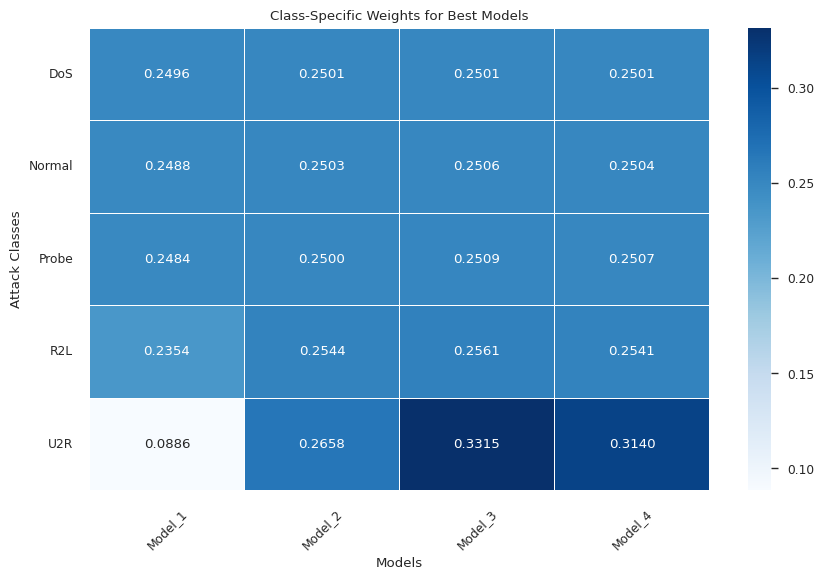

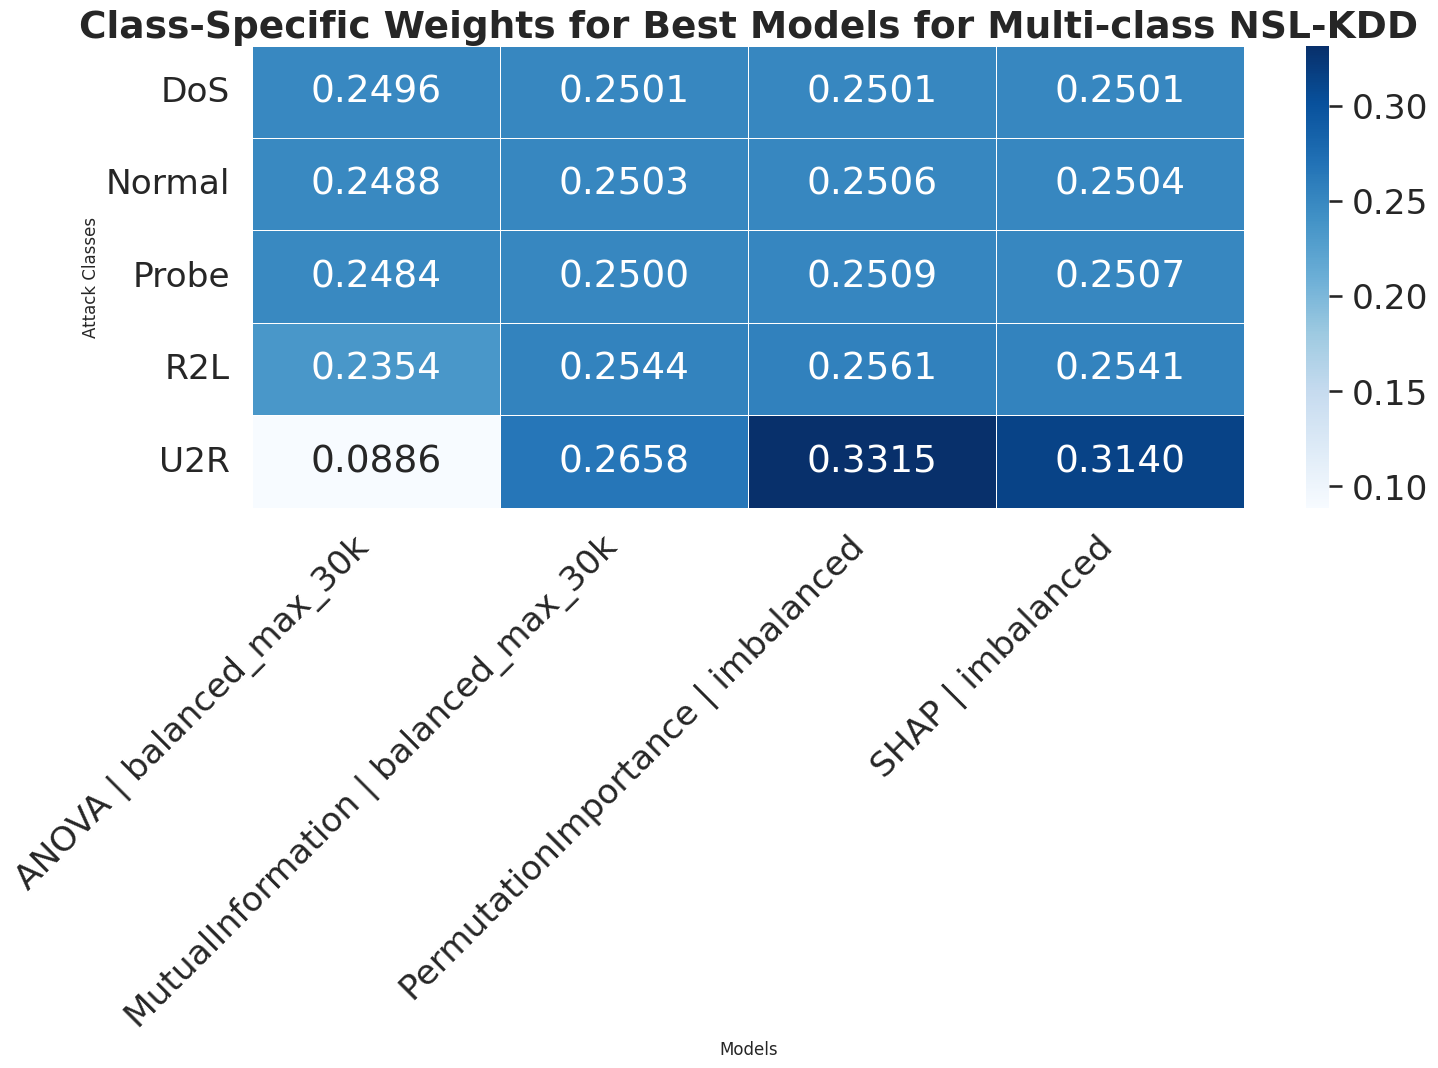

In [ ]:

class_weights_best = {} # {class_name: [weight_model_0, weight_model_1, ...]}


encoder_classes = global_encoder_for_ensemble.classes_ # Get consistent class order


# Create a pivot table of F1 scores for ALL models first
f1_scores_df_all = results_df[
    (results_df['metric'] == 'f1-score') &
    (results_df['class'].isin(encoder_classes))
].pivot_table(index=['view', 'balance'], columns='class', values='value')

# Create the multi-index corresponding to the best models *in the correct order*
best_model_multi_index = pd.MultiIndex.from_tuples(model_keys_best, names=['view', 'balance'])

# Select only the rows for the best models from the pivoted F1 scores
# Use reindex to handle potential missing entries gracefully
f1_scores_best_models = f1_scores_df_all.reindex(best_model_multi_index)

# Fill NaNs that might result if a best model combination was missing in results_df f1 scores
f1_scores_best_models.fillna(0.0, inplace=True)

# Check if any required classes are missing as columns (might happen if a class had 0 f1 everywhere)
missing_cols = [cls for cls in encoder_classes if cls not in f1_scores_best_models.columns]
if missing_cols:
    print(f"Warning: Columns for classes {missing_cols} not found in pivoted F1 scores. Weights for these classes might be inaccurate (defaulting to equal).")
    # Add missing columns with 0.0
    for col in missing_cols:
        f1_scores_best_models[col] = 0.0

# Calculate weights per class
for class_name in encoder_classes:
    # Get F1 scores for this class across the selected BEST models
    f1_for_class_best = f1_scores_best_models[class_name].values
    sum_f1_best = np.sum(f1_for_class_best)

    # Calculate normalized weights (handle sum=0 case)
    if sum_f1_best > 0:
        weights = f1_for_class_best / sum_f1_best
    else:
        # If all BEST models have 0 F1 for this class, assign equal weight
        print(f"Warning: All BEST models have 0 F1-score for class '{class_name}'. Assigning equal weights.")
        weights = np.ones(len(ensemble_models_best)) / len(ensemble_models_best)

    class_weights_best[class_name] = weights.tolist() # Store as list

    print("Class-specific weights calculated for BEST models.")
    print(class_weights_best)


weights_df = pd.DataFrame.from_dict(class_weights_best, orient='index', columns=[f'Model_{i+1}' for i in range(len(ensemble_models_best))])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(weights_df, annot=True,fmt=".4f" ,cmap="Blues", linewidths=0.5)

# Enhance visualization
plt.title("Class-Specific Weights for Best Models")
plt.xlabel("Models")
plt.ylabel("Attack Classes")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

model_names = [f"{view} | {balance}" for view, balance in model_keys_best]

# Create DataFrame with proper column names
weights_df = pd.DataFrame.from_dict(
    class_weights_best,
    orient='index',
    columns=model_names
)

# Show the plot
plt.show()

# Plot heatmap with model names
plt.figure(figsize=(16, 6))
sns.set_style("whitegrid")
sns.set_context("talk",font_scale=1.5)  # larger fonts for publication
sns.heatmap(weights_df, annot=True, fmt=".4f", cmap="Blues", linewidths=0.5)

plt.title("Class-Specific Weights for Best Models for Multi-class NSL-KDD",weight="bold")
plt.xlabel("Models",fontsize=12)
plt.ylabel("Attack Classes",fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
# Plot heatmaps for Precision, Recall, and F1-score




Decoding validation custom ensemble predictions...

Classification validation Report (Custom Weighted Soft Voting - BEST Models on val Set):
              precision    recall  f1-score   support

         DoS    0.99899   0.99937   0.99918      7947
      Normal    0.99472   0.99602   0.99537     11545
       Probe    0.99333   0.99618   0.99475      2093
         R2L    0.94876   0.92110   0.93473       583
         U2R    0.90909   0.55556   0.68966        18

    accuracy                        0.99491     22186
   macro avg    0.96898   0.89364   0.92274     22186
weighted avg    0.99484   0.99491   0.99484     22186

test Decoding custom ensemble predictions...

Classification test Report (Custom Weighted Soft Voting - BEST Models on testing Set):
              precision    recall  f1-score   support

         DoS    0.99950   0.99925   0.99937      7948
      Normal    0.99585   0.99749   0.99667     11545
       Probe    0.99666   0.99666   0.99666      2093
         R2L    0.96

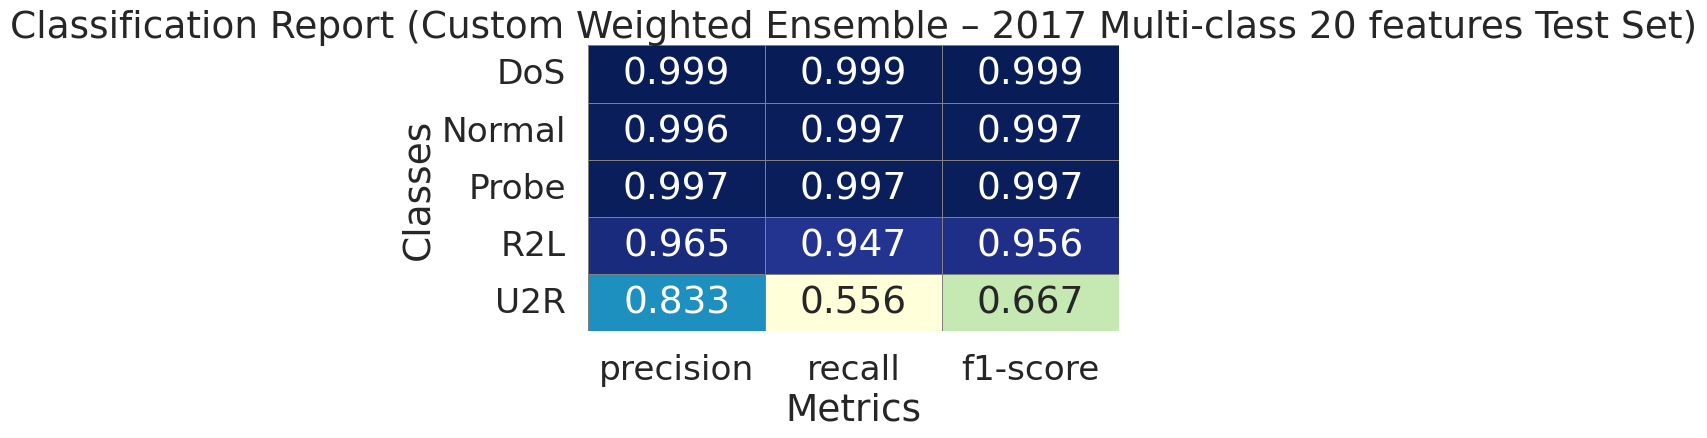

In [ ]:
X_test = test_df.drop(columns=['attack_category'])
y_test_str = test_df['attack_category']
X_val = val_df.drop(columns=['attack_category'])
y_val_str = val_df['attack_category']


y_pred_custom_encoded_best_val = predict_custom_weighted_soft(
      X_val,
      ensemble_models_best,   # Use the list of best models
      class_weights_best,   # Use the weights calculated for them
      global_encoder_for_ensemble
  )

print("Decoding validation custom ensemble predictions...")
y_pred_custom_str_best_val = global_encoder_for_ensemble.inverse_transform(y_pred_custom_encoded_best_val)

print("\nClassification validation Report (Custom Weighted Soft Voting - BEST Models on val Set):")
print(classification_report(y_val_str, y_pred_custom_str_best_val, labels=global_encoder_for_ensemble.classes_, zero_division=0,digits=5))


y_pred_custom_encoded_best = predict_custom_weighted_soft(
      X_test,
      ensemble_models_best,   # Use the list of best models
      class_weights_best,   # Use the weights calculated for them
      global_encoder_for_ensemble
  )

print("test Decoding custom ensemble predictions...")
y_pred_custom_str_best = global_encoder_for_ensemble.inverse_transform(y_pred_custom_encoded_best)

print("\nClassification test Report (Custom Weighted Soft Voting - BEST Models on testing Set):")
print(classification_report(y_test_str, y_pred_custom_str_best, labels=global_encoder_for_ensemble.classes_, zero_division=0,digits=5))

report_dict = classification_report(
    y_test_str,
    y_pred_custom_str_best,
    labels=global_encoder_for_ensemble.classes_,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Keep only per-class rows (drop avg/accuracy if you want)
class_metrics = report_df.loc[global_encoder_for_ensemble.classes_, ["precision", "recall", "f1-score"]]

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(class_metrics, annot=True, fmt=".3f", cmap="YlGnBu", cbar=False,
            linewidths=0.5, linecolor="gray")

plt.title("Classification Report (Custom Weighted Ensemble – 2017 Multi-class 20 features Test Set)")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


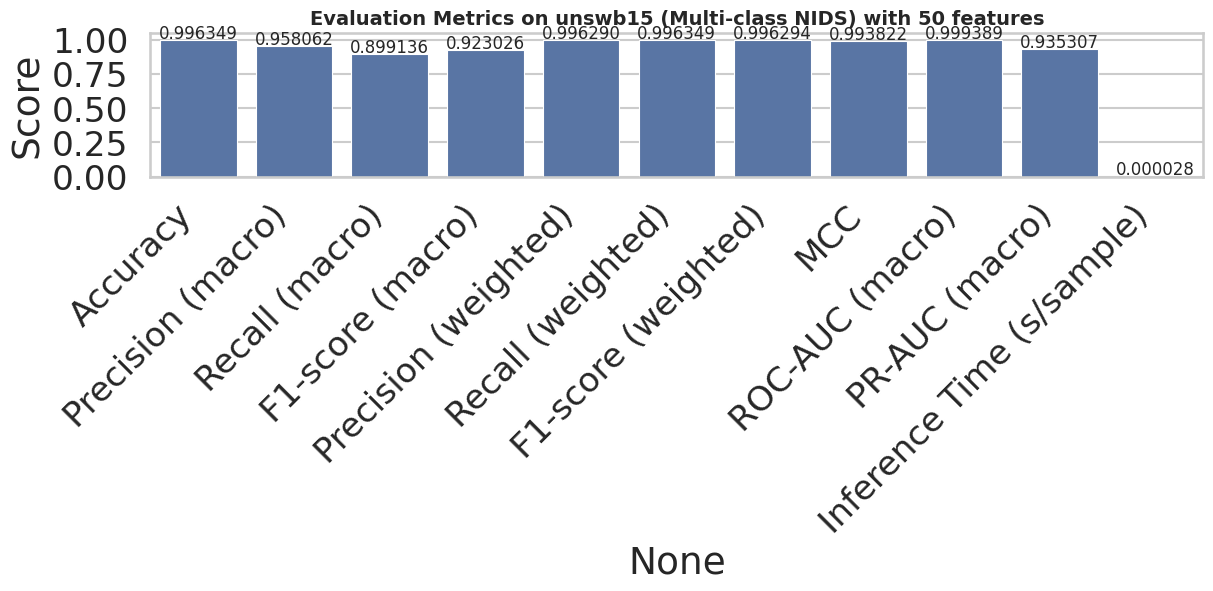

Inference time per sample: 0.000028 seconds
                              Value
Accuracy                   0.996349
Precision (macro)          0.958062
Recall (macro)             0.899136
F1-score (macro)           0.923026
Precision (weighted)       0.996290
Recall (weighted)          0.996349
F1-score (weighted)        0.996294
MCC                        0.993822
ROC-AUC (macro)            0.999389
PR-AUC (macro)             0.935307
Inference Time (s/sample)  0.000028


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import f1_score, recall_score, precision_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    matthews_corrcoef, recall_score, precision_score, f1_score, accuracy_score)


# --- Step 1: Predictions ---
start_time = time.time()
y_pred_custom_encoded_best = predict_custom_weighted_soft(
    X_test,
    ensemble_models_best,
    class_weights_best,
    global_encoder_for_ensemble
)
end_time = time.time()

y_pred_custom_str_best = global_encoder_for_ensemble.inverse_transform(y_pred_custom_encoded_best)

# Encode labels
y_test_enc = global_encoder_for_ensemble.transform(y_test_str)
y_pred_enc = global_encoder_for_ensemble.transform(y_pred_custom_str_best)

# --- Step 2: Metrics ---
acc = accuracy_score(y_test_enc, y_pred_enc)
prec_macro = precision_score(y_test_enc, y_pred_enc, average="macro")
rec_macro = recall_score(y_test_enc, y_pred_enc, average="macro")
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

prec_weighted = precision_score(y_test_enc, y_pred_enc, average="weighted")
rec_weighted = recall_score(y_test_enc, y_pred_enc, average="weighted")
f1_weighted = f1_score(y_test_enc, y_pred_enc, average="weighted")

mcc = matthews_corrcoef(y_test_enc, y_pred_enc)

# ROC-AUC & PR-AUC (macro-averaged)
y_pred_proba_test = predict_custom_weighted_soft(
    X_test,
    ensemble_models_best,
    class_weights_best,
    global_encoder_for_ensemble,
    return_proba=True
)

y_test_bin = label_binarize(y_test_enc, classes=range(len(global_encoder_for_ensemble.classes_)))
auroc_macro = roc_auc_score(y_test_bin, y_pred_proba_test, average="macro", multi_class="ovr")
aupr_macro = average_precision_score(y_test_bin, y_pred_proba_test, average="macro")

# Inference time
total_time = end_time - start_time
time_per_sample = total_time / len(X_test)

# --- Step 3: Collect Metrics ---
metrics_dict = {
    "Accuracy": acc,
    "Precision (macro)": prec_macro,
    "Recall (macro)": rec_macro,
    "F1-score (macro)": f1_macro,
    "Precision (weighted)": prec_weighted,
    "Recall (weighted)": rec_weighted,
    "F1-score (weighted)": f1_weighted,
    "MCC": mcc,
    "ROC-AUC (macro)": auroc_macro,
    "PR-AUC (macro)": aupr_macro,
    "Inference Time (s/sample)": time_per_sample
}

metrics_df = pd.DataFrame.from_dict(metrics_dict, orient="index", columns=["Value"])

# --- Step 4: Plot ---
fig, ax1 = plt.subplots(figsize=(12,6))

sns.set_style("whitegrid")
sns.set_context("paper")  # larger fonts for publication
sns.barplot(x=metrics_df.index, y="Value", data=metrics_df, ax=ax1, color="#4C72B0")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Score")
ax1.set_title("Evaluation Metrics on unswb15 (Multi-class NIDS) with 50 features",fontsize=14,weight="bold")

for i, v in enumerate(metrics_df["Value"]):
    ax1.text(i, v + 0.01, f"{v:.6f}" if v <= 1 else f"{v:.6f}", ha="center", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Inference time per sample: {time_per_sample:.6f} seconds")

print(metrics_df)


<>:61: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3716/208542101.py:61: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Classification Performance per Class\n(Macro-F1: {mean_f1:.4f} $\pm$ {std_f1:.4f})",


Calculated Metric: Macro-F1 = 0.9222 ± 0.0211


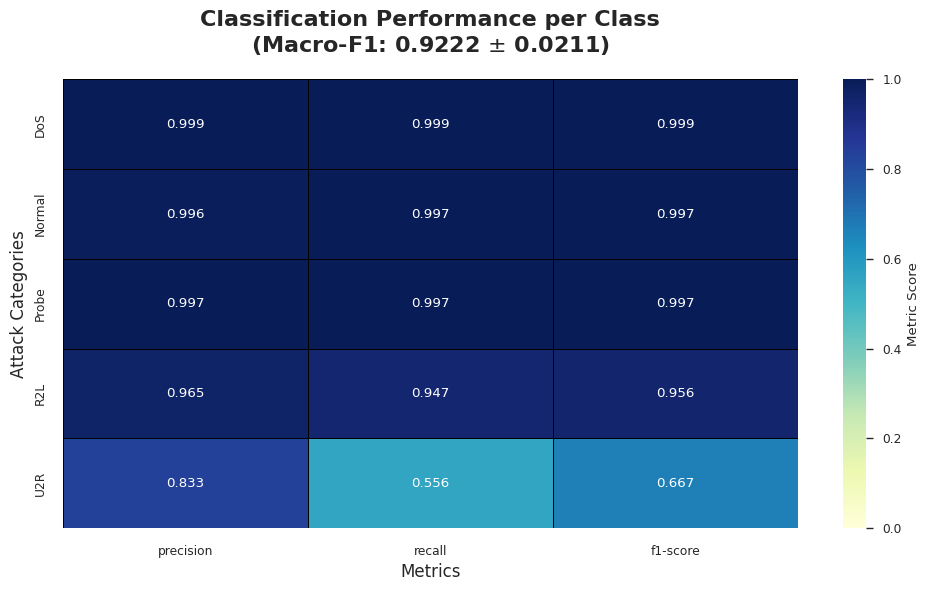

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score
from sklearn.utils import resample

# --- STEP 1: CALCULATE STATISTICAL ROBUSTNESS (BOOTSTRAP) ---
def get_bootstrap_metrics(y_true, y_pred, n_iter=1000):
    """Calculates Mean ± Std for Macro-F1 using resampling."""
    f1_scores = []
    # Convert to array for index-based resampling
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)

    for _ in range(n_iter):
        # Sample with replacement
        yt, yp = resample(y_true_arr, y_pred_arr, replace=True)
        # Calculate score (using macro average to avoid class bias)
        f1_scores.append(f1_score(yt, yp, average='macro'))

    return np.mean(f1_scores), np.std(f1_scores)

# Calculate your stats (Use your actual test data)
# Ensure y_test_str and y_pred_custom_str_best are defined in your env
mean_f1, std_f1 = get_bootstrap_metrics(y_test_str, y_pred_custom_str_best)
print(f"Calculated Metric: Macro-F1 = {mean_f1:.4f} ± {std_f1:.4f}")

# --- STEP 2: PREPARE DATA FOR HEATMAP (NO STRING PARSING) ---
# Generate report as a dictionary to avoid the "8.89" text parsing bug
report_dict = classification_report(
    y_test_str,
    y_pred_custom_str_best,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame and select only class rows
report_df = pd.DataFrame(report_dict).transpose()
# Filter for classes only (drop 'accuracy', 'macro avg', etc. to clean up)
classes_to_plot = [c for c in report_df.index if c not in ['accuracy', 'macro avg', 'weighted avg']]
class_metrics = report_df.loc[classes_to_plot, ["precision", "recall", "f1-score"]]

# --- STEP 3: CREATE PUBLICATION-READY HEATMAP ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the heatmap
ax = sns.heatmap(
    class_metrics,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Metric Score'},
    linewidths=0.5,
    linecolor="black",
    vmin=0, vmax=1  # Force scale to 0-1
)

# Add the Statistical Variance to the Title
plt.title(f"Classification Performance per Class\n(Macro-F1: {mean_f1:.4f} $\pm$ {std_f1:.4f})",
          fontsize=16, fontweight='bold', pad=20)

plt.ylabel("Attack Categories", fontsize=12)
plt.xlabel("Metrics", fontsize=12)
plt.tight_layout()

# Save for your paper
plt.savefig("performance_heatmap.pdf", dpi=300)
plt.show()